In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.style.use('sci.mplstyle')

In [9]:
def dieukienbien(n, u_bottom, u_left, u_right, u_top):
    u = np.zeros((n, n), dtype=float)

    # u[i,0] = bottom
    for i in range(n):
        u[i, 0] = u_bottom

    # u[0,j] = left
    for j in range(n):
        u[0, j] = u_left

    # u[n-1,j] = right
    for j in range(n):
        u[n-1, j] = u_right

    # u[i,n-1] = top
    for i in range(n):
        u[i, n-1] = u_top

    return u

In [10]:
def luufile_gauss_seidel(k,u,err,L,prefixfilename,final):
    if final == True:
        filename = f"{'final'}_{prefixfilename}_{k}.txt"
    else:
        filename = f"{'khonghoitu'}_{prefixfilename}_{k}.txt"
    with open(f"{filename}", "w", encoding="utf-8") as file:
        file.write(f"### Ket qua tinh toan tai vong lap {k}\n\n")
        file.write(f"### Do chinh xac: {np.max(err):.6e}\n\n")
        file.write(f"#" * 100 + "\n" + "\n")
        file.write(f"### {'x':>15s} {'y':>15s} {'V':>15s} {'Error':>15s}\n")
        for i in range(u.shape[0]):
            for j in range(u.shape[1]):
                x = 0 + i * L / (u.shape[0] - 1)
                y = 0 + j * L / (u.shape[1] - 1)
                file.write(f"    {x:15.6f} {y:15.6f} {u[i][j]:15.6f} {err[i][j]:15.6f}\n")
            file.write(f"\n") 

In [ ]:
def Jacobi(n,u,L,N_max,err_max,baitap):
    converged = False
    for k in range(N_max):
        u_old = u.copy()
        #for i in range(1, n-1):
        #    for j in range(1, n-1):
        #        u[i, j] = 0.25 * (u[i+1, j] + u[i-1, j] + u[i, j+1] + u[i, j-1])

        u[1:-1, 1:-1] = 0.25 * (u[2:,  1:-1] + u[:-2, 1:-1] + u[1:-1, 2:]  + u[1:-1, :-2])
        
        err = np.abs(u - u_old)
        if np.max(err) < err_max:
            converged = True
            print(f"Da hoi tu sau {k} vong lap, max_err = {np.max(err):.2e}")
            luufile_gauss_seidel(k,u,err,L,baitap,final=True)
            break

    if not converged:
        print(f"Khong hoi tu sau {N_max} vòng lặp, max_err = {np.max(err):.2e}")
        luufile_gauss_seidel(k, u, err, L, baitap, final=False)
    return u

In [ ]:
L = 100
n = 100
N_max = 100000
err_max = 1e-6
u = dieukienbien(n, 0, 0, 0, 100)
Jacobi(n,u,L,N_max,err_max,baitap="baiso1")

Da hoi tu sau 19705 vong lap, max_err = 1.00e-06


array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 1.00000000e+02],
       [0.00000000e+00, 1.11637980e-02, 2.23393483e-02, ...,
        3.02123988e+01, 4.99888322e+01, 1.00000000e+02],
       [0.00000000e+00, 2.23158476e-02, 4.46551834e-02, ...,
        4.99553288e+01, 6.97429300e+01, 1.00000000e+02],
       ...,
       [0.00000000e+00, 2.23158476e-02, 4.46551834e-02, ...,
        4.99553288e+01, 6.97429300e+01, 1.00000000e+02],
       [0.00000000e+00, 1.11637980e-02, 2.23393483e-02, ...,
        3.02123988e+01, 4.99888322e+01, 1.00000000e+02],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 1.00000000e+02]], shape=(100, 100))

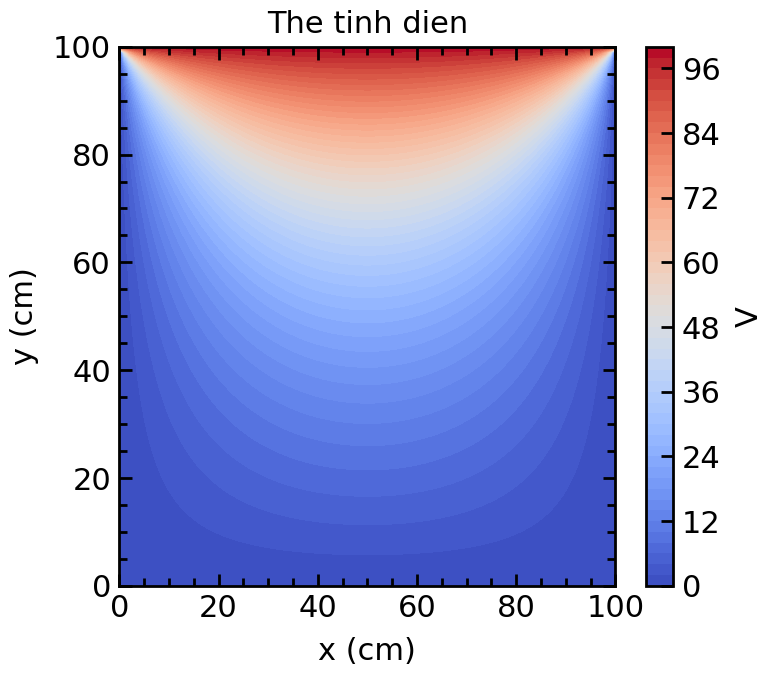

In [111]:
x, y, V, err = np.loadtxt("final_baiso1_19705.txt", comments='#', unpack=True)

n = int(np.sqrt(len(x)))
X = x.reshape(n, n)
Y = y.reshape(n, n)
V2D = V.reshape(n, n)

plt.figure(figsize=(8, 7))
plt.contourf(X, Y, V2D, levels=50, cmap='coolwarm')
plt.colorbar(label='V')
plt.xlabel('x (cm)')
plt.ylabel('y (cm)')
plt.title('The tinh dien')
plt.savefig("BTVN6-PDE-Thetinhdien-cmap.png", dpi=300)
plt.show()

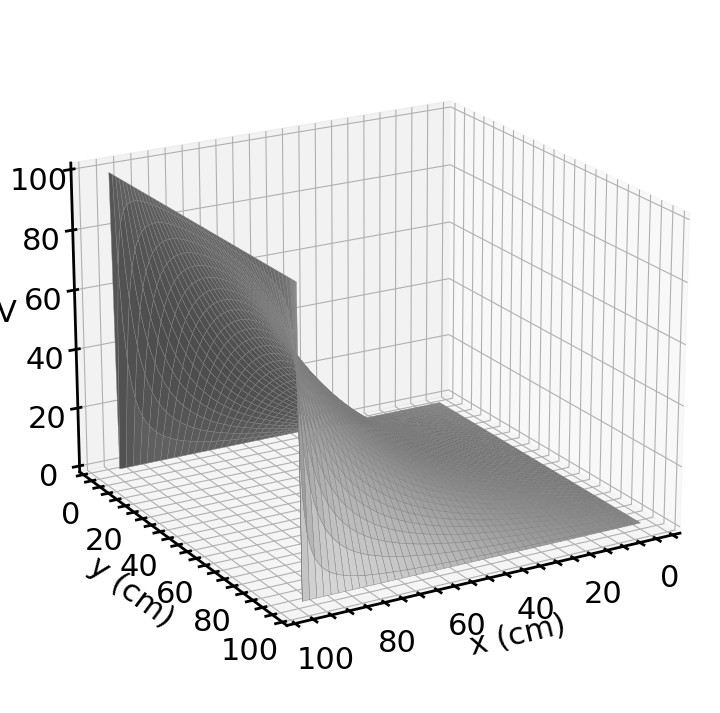

In [109]:
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, V2D.T, color='white', edgecolor='gray', linewidth=0.3)
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.set_zlabel('V')
ax.view_init(elev=20, azim=60)
plt.savefig("BTVN6-PDE-Thetinhdien-3D.png", dpi=300)
plt.show()

## Bai so 2 (2 thanh -100 V va 100 V)

In [13]:
def dieukienbien_bai2(n, u_bien, u_thap, u_cao, chieudai, chieurong, L):

    #length nhap vo la chieu ngang/boundary ngang, width nhap vo la chieu doc/boundary doc

    u = np.zeros((n, n), dtype=float)

    # u[i,0] = bottom
    for i in range(n):
        u[i, 0] = u_bien

    # u[0,j] = left
    for j in range(n):
        u[0, j] = u_bien

    # u[n-1,j] = right
    for j in range(n):
        u[n-1, j] = u_bien

    # u[i,n-1] = top
    for i in range(n):
        u[i, n-1] = u_bien

    # Thanh co chieu ngang tu (n-chieudai)/2 den (n+chieudai)/2, chieu doc nam o n+(chieurong/2) co dien ap u_cao
    # Thanh co chieu ngang tu (n-chieudai)/2 den (n+chieudai)/2, chieu doc nam o n-(chieurong/2) co dien ap u_thap

    n_chieudai  = int(chieudai  / L * (n - 1))   # 50/100 * 99 = 49
    n_chieurong = int(chieurong / L * (n - 1))   # 30/100 * 99 = 29

    n_center = n // 2
    thanh_o_tren = n_center + n_chieurong // 2
    thanh_o_duoi = n_center - n_chieurong // 2

    start  = (n-n_chieudai) // 2
    end = start + n_chieudai

    for i in range(start, end):
        u[i, thanh_o_tren] = u_cao
        u[i, thanh_o_duoi] = u_thap

    return u, start, end, thanh_o_tren, thanh_o_duoi

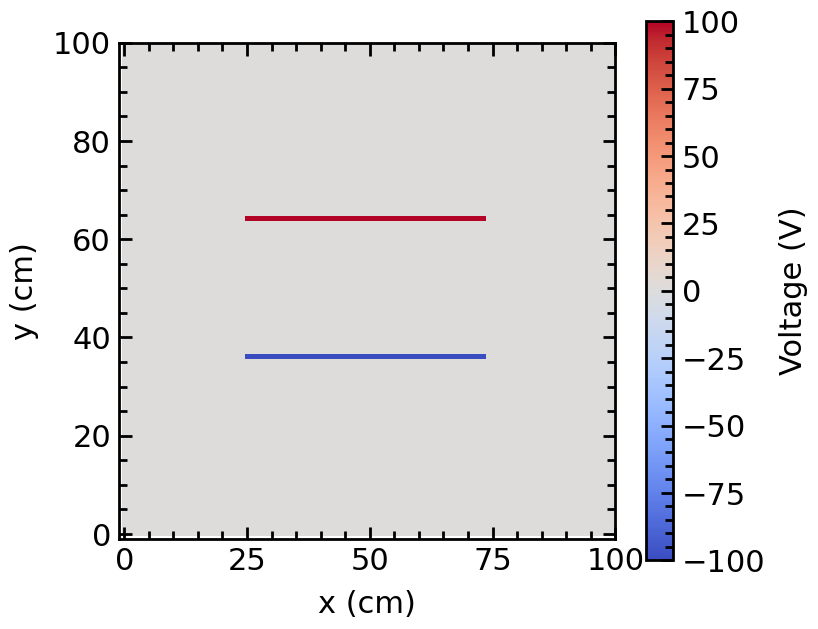

In [14]:
L = 100
n = 100
u_bien = 0
u_thap = -100
u_cao = 100
chieudai = 50
chieurong = 30

# Kiem tra dieu kien bien 
u_bien_bai2, start_bai2, end_bai2, thanh_o_tren_bai2, thanh_o_duoi_bai2 = dieukienbien_bai2(n, u_bien, u_thap, u_cao, chieudai, chieurong, L)
plt.figure(figsize=(8, 7))
plt.imshow(u_bien_bai2.T, origin='lower', cmap='coolwarm')
plt.xlim(-1, 100)
plt.ylim(-1, 100)
plt.xlabel('x (cm)')
plt.ylabel('y (cm)')
plt.colorbar(label='Voltage (V)')
plt.show()
N_max = 100000
err_max = 1e-6

In [ ]:
def Gauss_Seidel(n,u,L,N_max,err_max,baitap,start, end, thanh_o_tren, thanh_o_duoi):
    converged = False
    for k in range(N_max):
        u_old = u.copy()
        
        for i in range(1, n-1):
            for j in range(1, n-1):
                if start <= i < end and (j == thanh_o_tren or j == thanh_o_duoi):
                    continue
                u[i, j] = 0.25 * (u[i+1, j] + u[i-1, j] + u[i, j+1] + u[i, j-1])

        #u[1:-1, 1:-1] = 0.25 * (u[2:,  1:-1] + u[:-2, 1:-1] + u[1:-1, 2:]  + u[1:-1, :-2])
        
        err = np.abs(u - u_old)
        if np.max(err) < err_max:
            converged = True
            print(f"Da hoi tu sau {k} vong lap, max_err = {np.max(err):.2e}")
            luufile_gauss_seidel(k,u,err,L,baitap,final=True)
            break

    if not converged:
        print(f"Khong hoi tu sau {N_max} vòng lặp, max_err = {np.max(err):.2e}")
        luufile_gauss_seidel(k, u, err, L, baitap, final=False)
    return u


u_result_bai2 = Gauss_Seidel(n,u_bien_bai2,L,N_max,err_max,baitap="baiso2",start=start_bai2, end=end_bai2, thanh_o_tren=thanh_o_tren_bai2, thanh_o_duoi=thanh_o_duoi_bai2)

Da hoi tu sau 3009 vong lap, max_err = 9.98e-07


Locator attempting to generate 1001 ticks ([-100.0, ..., 100.0]), which exceeds Locator.MAXTICKS (1000).


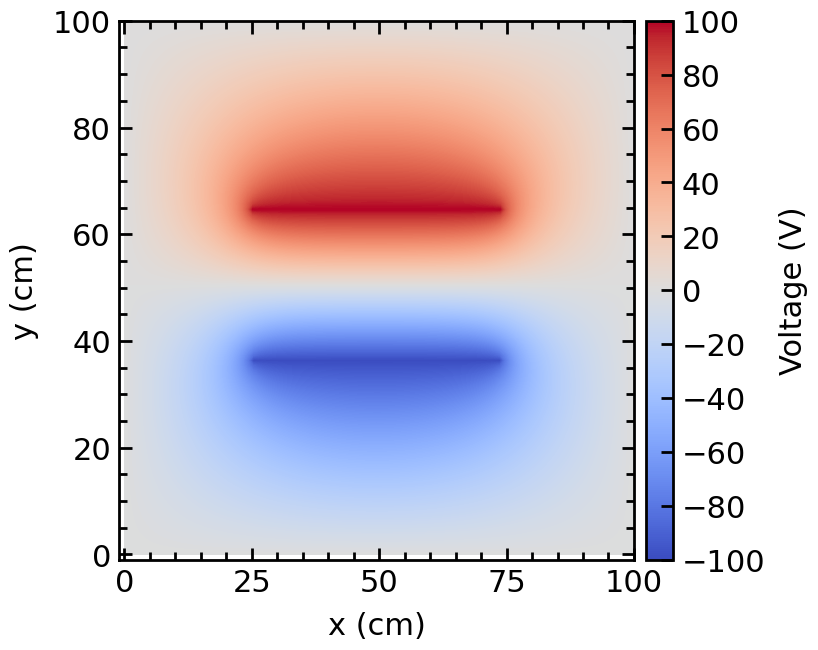

In [16]:
x_bai2, y_bai2, V_bai2, err_bai2 = np.loadtxt("final_baiso2_3009.txt", comments='#', unpack=True)

n = int(np.sqrt(len(x_bai2)))
X_bai2 = x_bai2.reshape(n, n)
Y_bai2 = y_bai2.reshape(n, n)
V2D_bai2 = V_bai2.reshape(n, n)

norm = mcolors.Normalize(vmin=-100, vmax=100)


plt.figure(figsize=(8, 7))
plt.contourf(X_bai2, Y_bai2, V2D_bai2, levels=1000, cmap='coolwarm', norm=norm)
plt.xlim(-1, 100)
plt.ylim(-1, 100)
plt.xlabel('x (cm)')
plt.ylabel('y (cm)')
cb = plt.colorbar(label='Voltage (V)', orientation='vertical', pad=0.02)
cb.set_ticks(np.arange(-100, 101, 20))
plt.savefig("BTVN6-PDE-Thetinhdien-bai2-cmap.png", dpi=300)
plt.show()

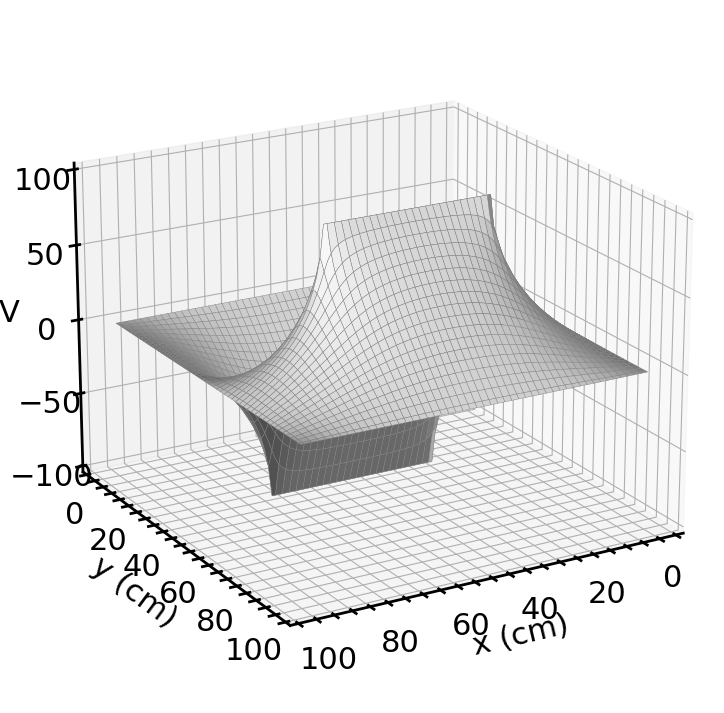

In [108]:
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X_bai2, Y_bai2, V2D_bai2, color='white', edgecolor='gray', linewidth=0.3)
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.set_zlabel('V')
ax.view_init(elev=20, azim=60)
plt.savefig("BTVN6-PDE-Thetinhdien-bai2-3D.png", dpi=300)
plt.show()